In [5]:
!pip install git+https://github.com/renzoliu29/simplegrad.git

  Cloning https://github.com/renzoliu29/simplegrad.git to /tmp/pip-req-build-mxwnx384
  Running command git clone --filter=blob:none --quiet https://github.com/renzoliu29/simplegrad.git /tmp/pip-req-build-mxwnx384
  Resolved https://github.com/renzoliu29/simplegrad.git to commit 8f26138d905e82bd3f07a453705f71694cc2d557
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for simplegrad: filename=simplegrad-0.1.0-py3-none-any.whl size=2681 sha256=2873a538f2b9c7958de34d186e2b547d63128f75b2d7a74e8c195d02ed004cf4
  Stored in directory: /tmp/pip-ephem-wheel-cache-fmqvpd_l/wheels/dd/f4/f8/6e38c433886c1ad5d28a0a669a17cb502de2e448d9201eb6ab
Successfully built simplegrad


In [6]:
from simplegrad import Value, Neuron, Layer, MLP

In [7]:
import numpy as np
import random
import matplotlib.pyplot as plt
%matplotlib inline

In [8]:
np.random.seed(1337)
random.seed(1337)

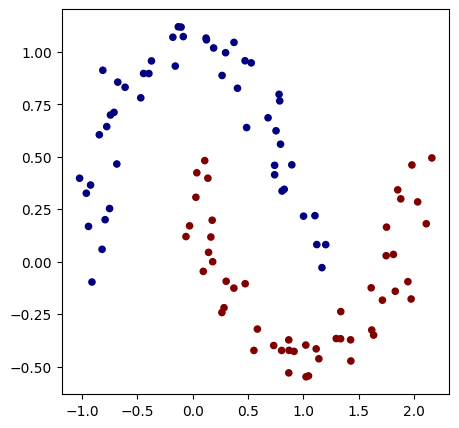

In [9]:
# make up a dataset

from sklearn.datasets import make_moons, make_blobs
X, y = make_moons(n_samples = 100, noise = 0.1)

y = y * 2 - 1 # make y be -1 or 1
# visualize in 2D
plt.figure(figsize=(5, 5))
plt.scatter(X[:, 0], X[:, 1], c = y, s = 20, cmap = 'jet')

In [10]:
# initlize a model
model = MLP(2, [16, 16, 1])
print(model)
print("number of parameters: ", len(model.parameters()))

number of parameters:  337


In [14]:
# loss function
def loss(batch_size = None):

  # inline DataLoader :)
  if batch_size is None:
    xb, yb = X, y
  else:
    ri = np.random.permutation(X.shape[0])[: batch_size]
    xb, yb = X[ri], y[ri]

  # forward the model to get scores
  inputs = [list(map(Value, xrow)) for xrow in xb]

  scores = list(map(model, inputs))

  # svm "max-margin" loss
  losses = list((1 - yi * si).relu() for yi, si in zip(yb, scores))
  data_loss = sum(losses) / len(losses)
  # L2 regularization
  alpha = 1e-4
  reg_loss = alpha * sum(p * p for p in model.parameters())
  total_loss = data_loss + reg_loss

  accuracies = [(yi > 0) == (si.data > 0) for yi, si in zip(yb, scores)]

  # also get accuracy
  return total_loss, sum(accuracies) / len(accuracies)

total_loss, acc = loss()
print(total_loss, acc)

Value (data=0.7840043023159258) 0.68


In [15]:
# optimization
for k in range(100):

  # forward
  total_loss, acc = loss()

  # backward
  model.zero_grad()
  total_loss.backward()

  # update
  learning_rate = 1.0 - 0.9*k/100
  for p in model.parameters():
    p.data -= learning_rate * p.grad

  if k % 1 == 0:
    print(f"Step {k}: loss is {total_loss.data} and accuracy is {acc * 100}%")

Step 0: loss is 0.7840043023159258 and accuracy is 68.0%
Step 1: loss is 0.5346887893624206 and accuracy is 73.0%
Step 2: loss is 0.40486112398826374 and accuracy is 83.0%
Step 3: loss is 0.3380828095624803 and accuracy is 86.0%
Step 4: loss is 0.2942618979033041 and accuracy is 88.0%
Step 5: loss is 0.2713707188453524 and accuracy is 90.0%
Step 6: loss is 0.2557758037037018 and accuracy is 90.0%
Step 7: loss is 0.24353269446139997 and accuracy is 91.0%
Step 8: loss is 0.2331166633588174 and accuracy is 91.0%
Step 9: loss is 0.22371429713875018 and accuracy is 91.0%
Step 10: loss is 0.21478840620418216 and accuracy is 91.0%
Step 11: loss is 0.20603142190103874 and accuracy is 91.0%
Step 12: loss is 0.1972226427758724 and accuracy is 92.0%
Step 13: loss is 0.18824544635214926 and accuracy is 93.0%
Step 14: loss is 0.17902966856680746 and accuracy is 94.0%
Step 15: loss is 0.16967500545392217 and accuracy is 94.0%
Step 16: loss is 0.1603343984865978 and accuracy is 94.0%
Step 17: loss is

(-1.548639298268643, 1.951360701731357)

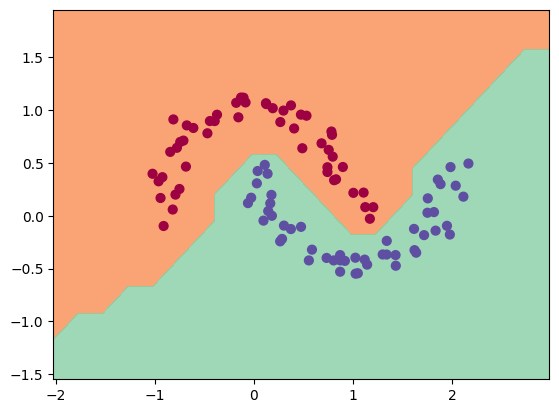

In [16]:
# visualize decision boundary

h = 0.25
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Xmesh = np.c_[xx.ravel(), yy.ravel()]
inputs = [list(map(Value, xrow)) for xrow in Xmesh]
scores = list(map(model, inputs))
Z = np.array([s.data > 0 for s in scores])
Z = Z.reshape(xx.shape)

fig = plt.figure()
plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())